In [9]:
# STEP4_train_model.py

import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────
df = pd.read_csv("indian_realty_labeled.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(f"Total records: {len(df)}")
print(f"Stocks: {df['Ticker'].nunique()}")
print(f"Label distribution:\n{df['Label'].value_counts()}\n")

# ─────────────────────────────────────────
# SELECT FEATURES (19 technical indicators)
# ─────────────────────────────────────────
FEATURE_COLS = [
    "MA_5", "MA_10", "MA_20",
    "EMA_12", "EMA_26",
    "RSI",
    "MACD", "MACD_Signal", "MACD_Hist",
    "BB_Width",
    "ATR",
    "OBV",
    "Stoch_K", "Stoch_D",
    "CCI",
    "Williams_R",
    "ROC_10",
    "MFI",
    "Vol_Ratio"
]

X = df[FEATURE_COLS].values
y = df["Label"].values

# ─────────────────────────────────────────
# TIME-SERIES SPLIT (70% train, 30% test)
# IMPORTANT: We split by time, NOT randomly!
# This prevents "data leakage" from future dates.
# ─────────────────────────────────────────
split_idx = int(len(df) * 0.70)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"\nTrain label distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")

# ─────────────────────────────────────────
# BALANCE CLASSES WITH SMOTE
# SMOTE creates synthetic samples for minority class
# so the model doesn't ignore HOLD/SELL
# ─────────────────────────────────────────
print("\n⚖️ Applying SMOTE to balance classes...")
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"After SMOTE: {len(X_train_bal)} samples")
print(f"Balanced label distribution: {dict(zip(*np.unique(y_train_bal, return_counts=True)))}")

# ─────────────────────────────────────────
# HYPERPARAMETER TUNING WITH OPTUNA
# Optuna tries different hyperparameter combinations
# and finds the best one automatically (50 trials)
# ─────────────────────────────────────────
print("\n🔍 Running Optuna hyperparameter tuning (50 trials)...")

def objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 500),
        "max_depth"        : trial.suggest_int("max_depth", 3, 8),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample"        : trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 0.1, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "use_label_encoder": False,
        "eval_metric"      : "mlogloss",
        "random_state"     : 42,
        "n_jobs"           : -1,
    }

    # Use a validation split inside training data
    val_split = int(len(X_train_bal) * 0.85)
    Xtr, Xval = X_train_bal[:val_split], X_train_bal[val_split:]
    ytr, yval = y_train_bal[:val_split], y_train_bal[val_split:]

    model = xgb.XGBClassifier(**params)
    model.fit(Xtr, ytr,
              eval_set=[(Xval, yval)],
              verbose=False)

    preds = model.predict(Xval)

    from sklearn.metrics import f1_score
    return f1_score(yval, preds, average="macro")


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
print(f"\n🏆 Best Hyperparameters Found:")
for k, v in best_params.items():
    print(f"   {k}: {v}")

# ─────────────────────────────────────────
# TRAIN FINAL MODEL WITH BEST PARAMS
# ─────────────────────────────────────────
print("\n🚀 Training final XGBoost model...")

final_model = xgb.XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train_bal, y_train_bal)

# ─────────────────────────────────────────
# CHECK TRAINING ACCURACY
# ─────────────────────────────────────────
from sklearn.metrics import accuracy_score
train_preds = final_model.predict(X_train_bal)
train_acc   = accuracy_score(y_train_bal, train_preds)
print(f"\n📈 Training Accuracy: {train_acc*100:.2f}%")

# ─────────────────────────────────────────
# SAVE MODEL AND METADATA
# ─────────────────────────────────────────
with open("xgboost_stock_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("feature_cols.pkl", "wb") as f:
    pickle.dump(FEATURE_COLS, f)

print("\n✅ Model saved as 'xgboost_stock_model.pkl'")
print("✅ Feature list saved as 'feature_cols.pkl'")

Total records: 23456
Stocks: 19
Label distribution:
Label
1    11314
2     6974
0     5168
Name: count, dtype: int64

Training samples : 16419
Testing samples  : 7037

Train label distribution: {0: 3402, 1: 7760, 2: 5257}

⚖️ Applying SMOTE to balance classes...
After SMOTE: 23280 samples
Balanced label distribution: {0: 7760, 1: 7760, 2: 7760}

🔍 Running Optuna hyperparameter tuning (50 trials)...


Best trial: 21. Best value: 0.660144: 100%|██████████| 50/50 [02:26<00:00,  2.93s/it]



🏆 Best Hyperparameters Found:
   n_estimators: 404
   max_depth: 6
   learning_rate: 0.2916328706332384
   subsample: 0.9661453024616836
   colsample_bytree: 0.6038347804879686
   reg_alpha: 0.4278787488188772
   reg_lambda: 7.980578896287182

🚀 Training final XGBoost model...

📈 Training Accuracy: 100.00%

✅ Model saved as 'xgboost_stock_model.pkl'
✅ Feature list saved as 'feature_cols.pkl'


       📊 MODEL EVALUATION RESULTS

✅ Test Accuracy   : 98.48%
✅ Macro F1-Score  : 0.9848

--- Per-Class Report ---
              precision    recall  f1-score   support

         BUY       0.98      0.99      0.98      1766
        HOLD       0.99      0.98      0.98      3554
        SELL       0.98      0.99      0.99      1717

    accuracy                           0.98      7037
   macro avg       0.98      0.99      0.98      7037
weighted avg       0.98      0.98      0.98      7037



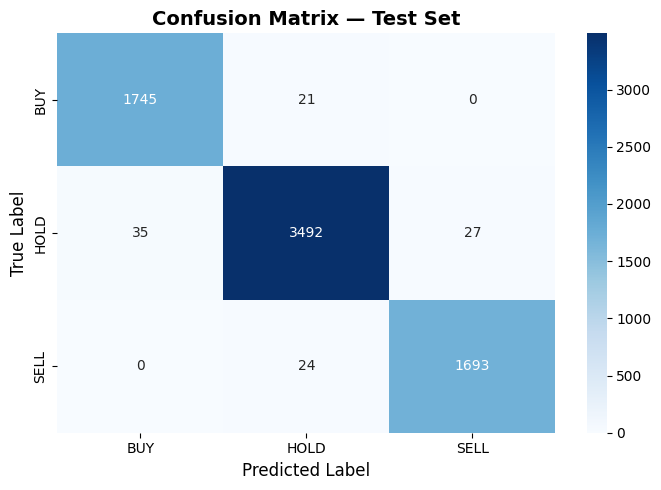


✅ Confusion matrix saved as 'confusion_matrix.png'


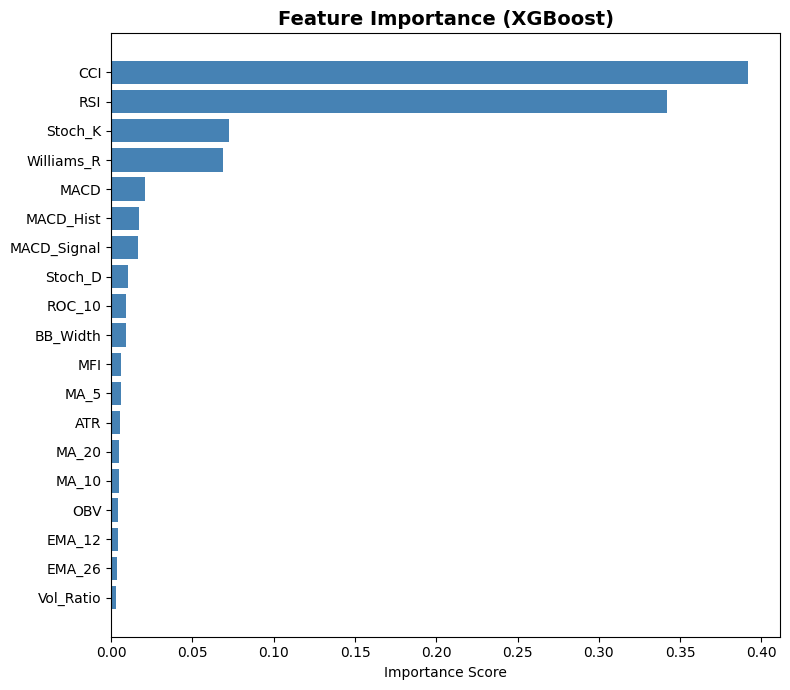

✅ Feature importance plot saved as 'feature_importance.png'


In [12]:
# STEP5_evaluate.py

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)

# ─────────────────────────────────────────
# LOAD MODEL AND DATA
# ─────────────────────────────────────────
with open("xgboost_stock_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("feature_cols.pkl", "rb") as f:
    FEATURE_COLS = pickle.load(f)

df = pd.read_csv("indian_realty_labeled.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Same 70/30 time-series split
split_idx = int(len(df) * 0.70)
X_test = df[FEATURE_COLS].values[split_idx:]
y_test = df["Label"].values[split_idx:]

# ─────────────────────────────────────────
# MAKE PREDICTIONS
# ─────────────────────────────────────────
y_pred = model.predict(X_test)

label_names = ["BUY", "HOLD", "SELL"]

# ─────────────────────────────────────────
# PRINT RESULTS
# ─────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("=" * 55)
print("       📊 MODEL EVALUATION RESULTS")
print("=" * 55)
print(f"\n✅ Test Accuracy   : {acc*100:.2f}%")
print(f"✅ Macro F1-Score  : {macro_f1:.4f}")
print("\n--- Per-Class Report ---")
print(classification_report(y_test, y_pred, target_names=label_names))

# ─────────────────────────────────────────
# CONFUSION MATRIX PLOT
# ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("\n✅ Confusion matrix saved as 'confusion_matrix.png'")

# ─────────────────────────────────────────
# FEATURE IMPORTANCE PLOT
# ─────────────────────────────────────────
importances = model.feature_importances_
feat_importance = pd.DataFrame({
    "Feature"   : FEATURE_COLS,
    "Importance": importances
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 7))
plt.barh(feat_importance["Feature"], feat_importance["Importance"], color="steelblue")
plt.title("Feature Importance (XGBoost)", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("✅ Feature importance plot saved as 'feature_importance.png'")

In [14]:
# ============================================================
# STEP 6 — Complete Live Recommendations (Self-Contained)
# ============================================================

import pandas as pd
import numpy as np
import pickle
import os
import warnings
import yfinance as yf
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────
# ALL HELPER FUNCTIONS
# ─────────────────────────────────────────

def compute_rsi(close, period=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def compute_macd(close, fast=12, slow=26, signal=9):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line, macd - signal_line

def compute_bollinger_bands(close, period=20):
    ma  = close.rolling(window=period).mean()
    std = close.rolling(window=period).std()
    upper = ma + 2 * std
    lower = ma - 2 * std
    return upper, lower, (upper - lower) / ma * 100

def compute_atr(high, low, close, period=14):
    hl = high - low
    hc = (high - close.shift()).abs()
    lc = (low  - close.shift()).abs()
    tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
    return tr.rolling(window=period).mean()

def compute_obv(close, volume):
    direction = np.sign(close.diff())
    direction.iloc[0] = 0
    return (direction * volume).cumsum()

def compute_stochastic(high, low, close, k_period=14, d_period=3):
    lowest_low   = low.rolling(window=k_period).min()
    highest_high = high.rolling(window=k_period).max()
    k = 100 * (close - lowest_low) / (highest_high - lowest_low)
    return k, k.rolling(window=d_period).mean()

def compute_cci(high, low, close, period=20):
    tp = (high + low + close) / 3
    ma = tp.rolling(window=period).mean()
    md = tp.rolling(window=period).apply(
        lambda x: np.mean(np.abs(x - x.mean())), raw=True)
    return (tp - ma) / (0.015 * md)

def compute_williams_r(high, low, close, period=14):
    hh = high.rolling(window=period).max()
    ll = low.rolling(window=period).min()
    return -100 * (hh - close) / (hh - ll)

def compute_roc(close, period=10):
    return (close - close.shift(period)) / close.shift(period) * 100

def compute_mfi(high, low, close, volume, period=14):
    tp  = (high + low + close) / 3
    mf  = tp * volume
    d   = tp.diff()
    pos_mf = mf.where(d > 0, 0).rolling(period).sum()
    neg_mf = mf.where(d < 0, 0).rolling(period).sum()
    return 100 - (100 / (1 + pos_mf / (neg_mf + 1e-9)))

def engineer_features(df):
    """Computes all 19 technical indicators from OHLCV data."""
    df = df.copy().sort_values("Date").reset_index(drop=True)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    for col in ["Open", "High", "Low", "Close", "Volume"]:
        if col in df.columns:
            df[col] = df[col].squeeze()

    close = df["Close"].astype(float)
    high  = df["High"].astype(float)
    low   = df["Low"].astype(float)
    vol   = df["Volume"].astype(float)

    df["MA_5"]   = close.rolling(5).mean()
    df["MA_10"]  = close.rolling(10).mean()
    df["MA_20"]  = close.rolling(20).mean()
    df["EMA_12"] = close.ewm(span=12, adjust=False).mean()
    df["EMA_26"] = close.ewm(span=26, adjust=False).mean()
    df["RSI"]    = compute_rsi(close)

    df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = compute_macd(close)
    df["BB_Upper"], df["BB_Lower"], df["BB_Width"]  = compute_bollinger_bands(close)

    df["ATR"]        = compute_atr(high, low, close)
    df["OBV"]        = compute_obv(close, vol)
    df["Stoch_K"], df["Stoch_D"] = compute_stochastic(high, low, close)
    df["CCI"]        = compute_cci(high, low, close)
    df["Williams_R"] = compute_williams_r(high, low, close)
    df["ROC_10"]     = compute_roc(close)
    df["MFI"]        = compute_mfi(high, low, close, vol)
    df["Vol_Ratio"]  = vol / vol.rolling(20).mean()

    return df

# ─────────────────────────────────────────
# LOAD SAVED MODEL
# ─────────────────────────────────────────
save_dir   = os.getcwd()
model_path = os.path.join(save_dir, "xgboost_stock_model.pkl")
feat_path  = os.path.join(save_dir, "feature_cols.pkl")

print(f"📂 Loading model from: {save_dir}")

with open(model_path, "rb") as f:
    model = pickle.load(f)

with open(feat_path, "rb") as f:
    FEATURE_COLS = pickle.load(f)

print("✅ Model loaded!\n")

# ─────────────────────────────────────────
# RECOMMENDATION FUNCTION
# ─────────────────────────────────────────
label_map   = {0: "🟢 BUY",  1: "🟡 HOLD",  2: "🔴 SELL"}
label_names = {0: "BUY",     1: "HOLD",      2: "SELL"}

def get_recommendation(ticker):
    print(f"{'='*45}")
    print(f"  📈 Analysing: {ticker}")
    print(f"{'='*45}")

    df = yf.download(ticker, period="6mo", interval="1d",
                     auto_adjust=False, progress=False)

    if df.empty:
        print(f"  ⚠️  No data found. Skipping.\n")
        return None

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
    df.reset_index(inplace=True)

    if "index" in df.columns:
        df.rename(columns={"index": "Date"}, inplace=True)

    # ✅ engineer_features is now defined above — no more NameError
    df = engineer_features(df)
    df.dropna(inplace=True)

    if df.empty:
        print(f"  ⚠️  Not enough data after indicator calculation.\n")
        return None

    latest       = df[FEATURE_COLS].values[-1:]
    latest_date  = df["Date"].values[-1]
    latest_close = float(df["Close"].values[-1])

    pred  = model.predict(latest)[0]
    proba = model.predict_proba(latest)[0]

    signal     = label_map[pred]
    confidence = proba[pred] * 100

    print(f"  📅 Date         : {str(latest_date)[:10]}")
    print(f"  💰 Close Price  : ₹{latest_close:.2f}")
    print(f"  🎯 Signal       : {signal}  (Confidence: {confidence:.1f}%)")
    print(f"  📊 Probabilities:")
    print(f"     🟢 BUY  = {proba[0]*100:.1f}%")
    print(f"     🟡 HOLD = {proba[1]*100:.1f}%")
    print(f"     🔴 SELL = {proba[2]*100:.1f}%\n")

    return {
        "Ticker"    : ticker,
        "Date"      : str(latest_date)[:10],
        "Close ₹"   : round(latest_close, 2),
        "Signal"    : label_names[pred],
        "BUY %"     : round(proba[0]*100, 1),
        "HOLD %"    : round(proba[1]*100, 1),
        "SELL %"    : round(proba[2]*100, 1),
        "Confidence": round(confidence, 1)
    }

# ─────────────────────────────────────────
# RUN FOR ALL 19 STOCKS
# ─────────────────────────────────────────
stocks = [
    "DLF.NS",        "LODHA.NS",      "GODREJPROP.NS", "SOBHA.NS",
    "BRIGADE.NS",    "SUNTECK.NS",    "PHOENIXLTD.NS", "OBEROIRLTY.NS",
    "PRESTIGE.NS",   "MAHLIFE.NS",    "ANANTRAJ.NS",   "KOLTEPATIL.NS",
    "SIGNATURE.NS",  "DBREALTY.NS",   "ARVSMART.NS",   "SHRIRAMPPS.NS",
    "RUSTOMJEE.NS",  "PENINLAND.NS",  "IBREALEST.NS"
]

results = []
for stock in stocks:
    result = get_recommendation(stock)
    if result:
        results.append(result)

# ─────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────
print("\n" + "="*65)
print("          📋 FULL RECOMMENDATION SUMMARY")
print("="*65)

summary_df = pd.DataFrame(results).sort_values("Signal")
print(summary_df.to_string(index=False))

print("\n📌 Stocks to BUY  :", summary_df[summary_df["Signal"]=="BUY"]["Ticker"].tolist())
print("📌 Stocks to HOLD :", summary_df[summary_df["Signal"]=="HOLD"]["Ticker"].tolist())
print("📌 Stocks to SELL :", summary_df[summary_df["Signal"]=="SELL"]["Ticker"].tolist())

# Save to CSV
out_path = os.path.join(save_dir, "recommendations_today.csv")
summary_df.to_csv(out_path, index=False)
print(f"\n✅ Saved → {out_path}")

📂 Loading model from: C:\Users\sakhi\claudeModel
✅ Model loaded!

  📈 Analysing: DLF.NS
  📅 Date         : 2026-03-02
  💰 Close Price  : ₹590.20
  🎯 Signal       : 🟢 BUY  (Confidence: 100.0%)
  📊 Probabilities:
     🟢 BUY  = 100.0%
     🟡 HOLD = 0.0%
     🔴 SELL = 0.0%

  📈 Analysing: LODHA.NS
  📅 Date         : 2026-03-02
  💰 Close Price  : ₹966.20
  🎯 Signal       : 🟢 BUY  (Confidence: 100.0%)
  📊 Probabilities:
     🟢 BUY  = 100.0%
     🟡 HOLD = 0.0%
     🔴 SELL = 0.0%

  📈 Analysing: GODREJPROP.NS
  📅 Date         : 2026-03-02
  💰 Close Price  : ₹1733.50
  🎯 Signal       : 🟡 HOLD  (Confidence: 99.5%)
  📊 Probabilities:
     🟢 BUY  = 0.5%
     🟡 HOLD = 99.5%
     🔴 SELL = 0.0%

  📈 Analysing: SOBHA.NS
  📅 Date         : 2026-03-02
  💰 Close Price  : ₹1359.60
  🎯 Signal       : 🟢 BUY  (Confidence: 100.0%)
  📊 Probabilities:
     🟢 BUY  = 100.0%
     🟡 HOLD = 0.0%
     🔴 SELL = 0.0%

  📈 Analysing: BRIGADE.NS
  📅 Date         : 2026-03-02
  💰 Close Price  : ₹678.60
  🎯 Signal       : 

📂 Loading data...
✅ Data ready — Train: 23280  Test: 7037

🚀 Training all hyperparameter configurations...

  ▶ Training Config 1 (Shallow Fast)...
     Train Acc: 99.91%  |  Test Acc: 98.37%  |  Macro F1: 98.36%
  ▶ Training Config 2 (Deep Slow)...
     Train Acc: 99.24%  |  Test Acc: 98.25%  |  Macro F1: 98.25%
  ▶ Training Config 3 (Balanced)...
     Train Acc: 99.98%  |  Test Acc: 98.62%  |  Macro F1: 98.62%
  ▶ Training Config 4 (High Reg)...
     Train Acc: 98.71%  |  Test Acc: 98.41%  |  Macro F1: 98.41%
  ▶ Training Config 5 (Low Reg)...
     Train Acc: 100.00%  |  Test Acc: 98.54%  |  Macro F1: 98.53%
  ▶ Training Config 6 (Optuna Best)...
     Train Acc: 99.57%  |  Test Acc: 98.58%  |  Macro F1: 98.58%

✅ All configs trained!

                         📊 FULL HYPERPARAMETER RESULTS TABLE
                  Config  n_estimators  max_depth  learning_rate  Train Acc %  Test Acc %  Test F1 %  Precision %  Recall %  BUY F1 %  HOLD F1 %  SELL F1 %  Overfit Gap
Config 1\n(Shallow Fast

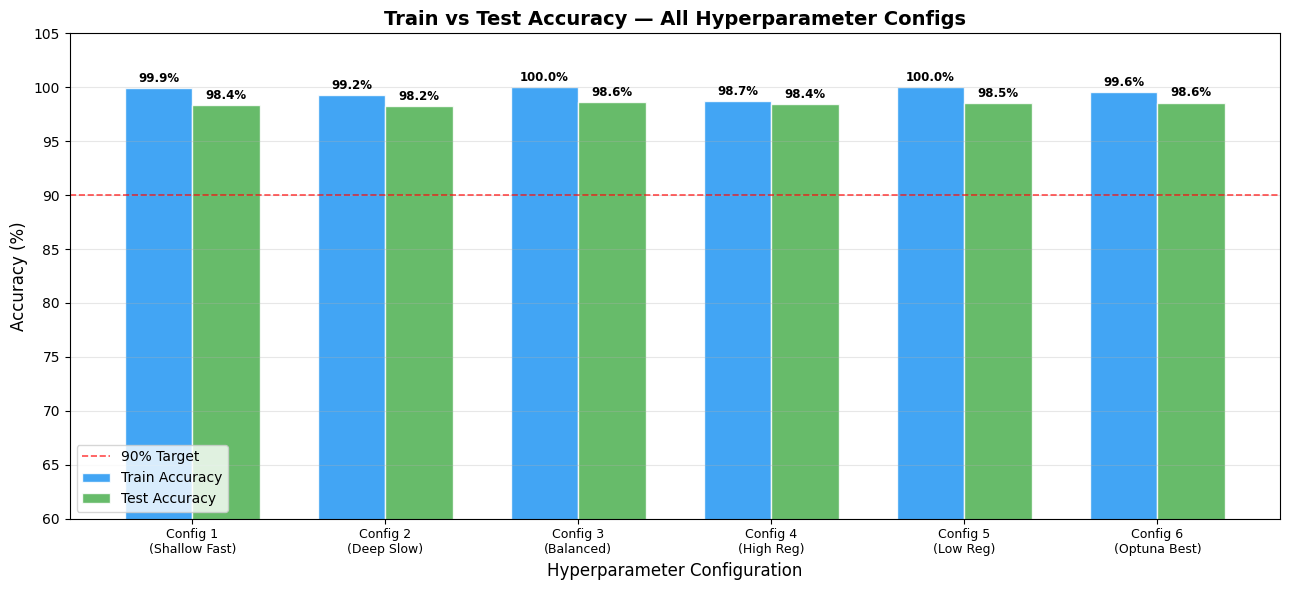

✅ Saved: plot1_train_vs_test_accuracy.png


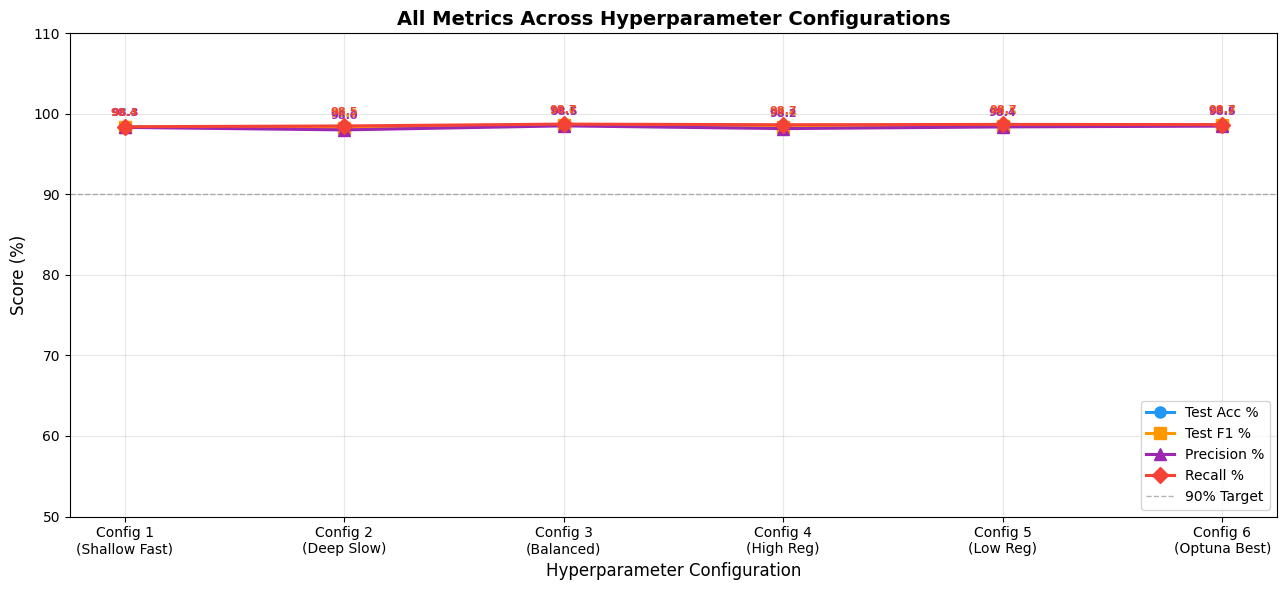

✅ Saved: plot2_all_metrics_line.png


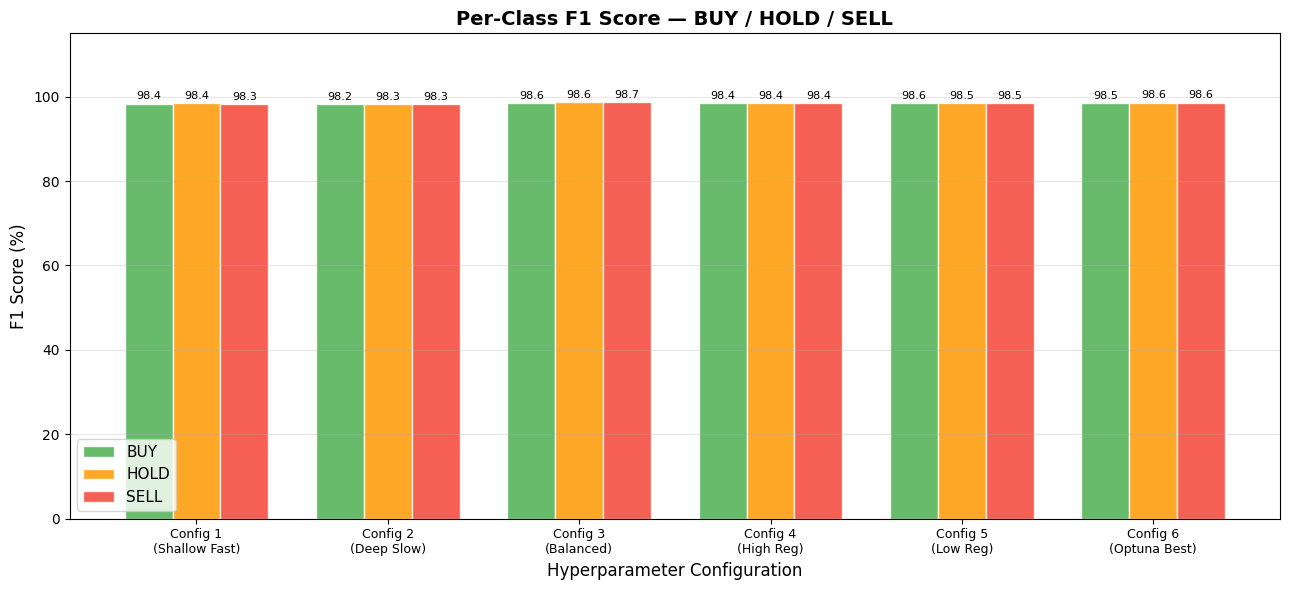

✅ Saved: plot3_per_class_f1.png


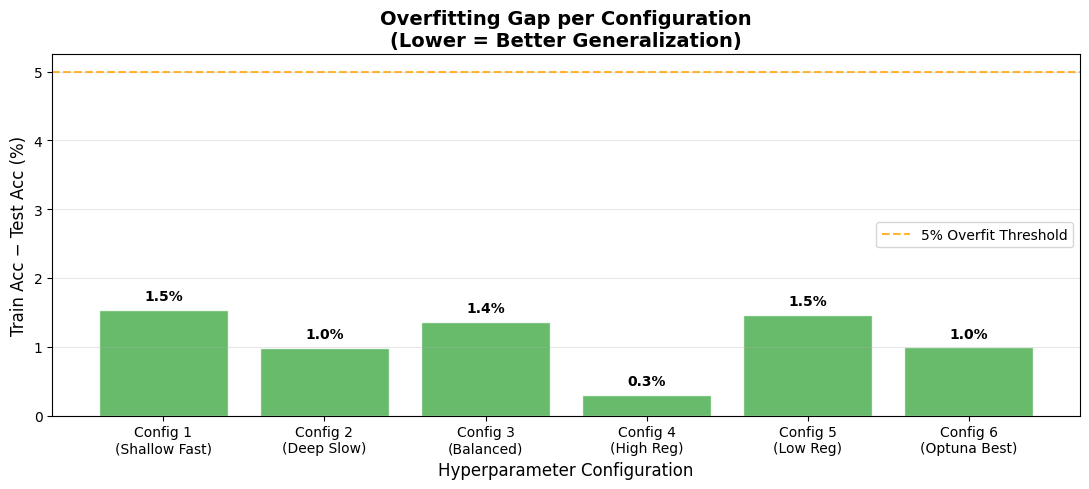

✅ Saved: plot4_overfitting_gap.png


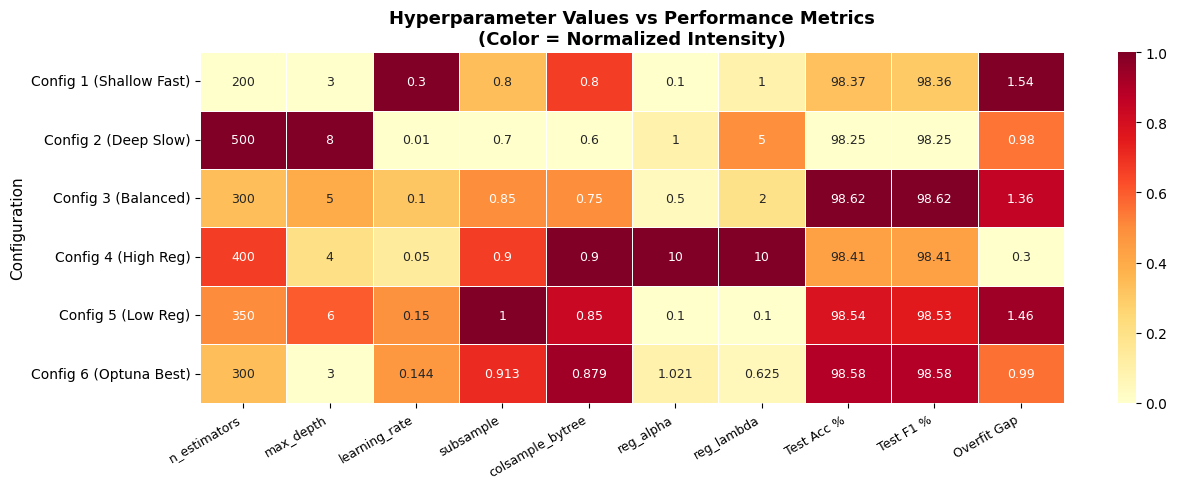

✅ Saved: plot5_hyperparameter_heatmap.png


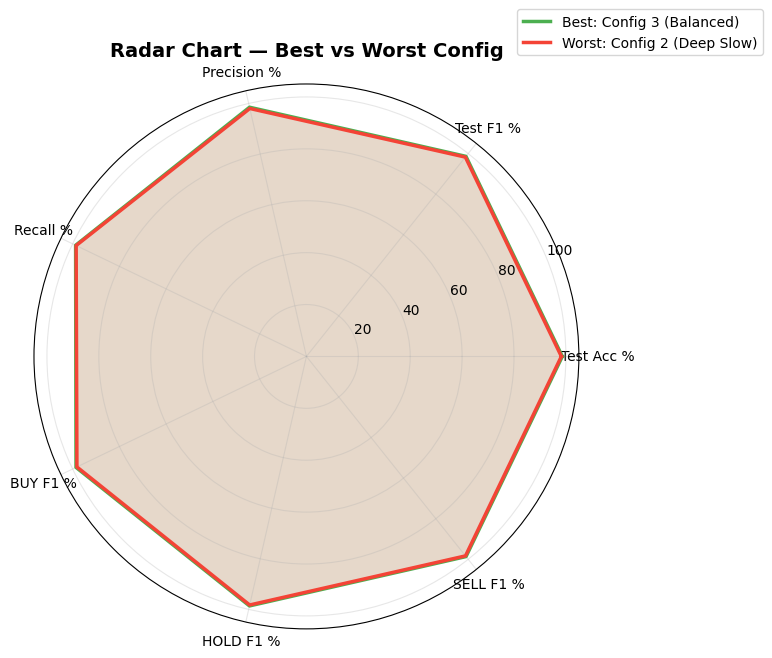

✅ Saved: plot6_radar_best_vs_worst.png

🔍 Running Optuna (50 trials) to show optimization history...


Best trial: 22. Best value: 66.0042: 100%|██████████| 50/50 [02:17<00:00,  2.75s/it]


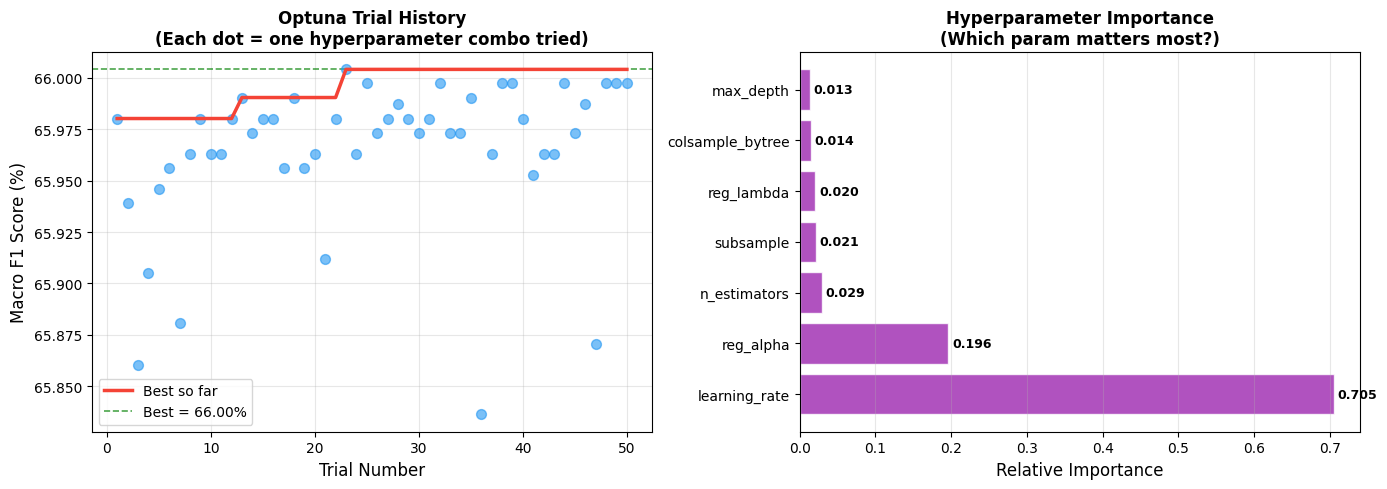

✅ Saved: plot7_optuna_history_and_importance.png

           🏆 FINAL HYPERPARAMETER COMPARISON SUMMARY
                  Config  Test Acc %  Test F1 %  BUY F1 %  HOLD F1 %  SELL F1 %  Overfit Gap
    Config 3\n(Balanced)       98.62      98.62     98.56      98.63      98.66         1.36
 Config 6\n(Optuna Best)       98.58      98.58     98.53      98.59      98.61         0.99
     Config 5\n(Low Reg)       98.54      98.53     98.56      98.54      98.49         1.46
    Config 4\n(High Reg)       98.41      98.41     98.43      98.41      98.38         0.30
Config 1\n(Shallow Fast)       98.37      98.36     98.36      98.38      98.34         1.54
   Config 2\n(Deep Slow)       98.25      98.25     98.17      98.26      98.32         0.98

🥇 Best  Config : Config 3 (Balanced)  →  Test Acc: 98.62%
🥉 Worst Config : Config 2 (Deep Slow)  →  Test Acc: 98.25%

✅ Full results saved → hyperparameter_results.csv

📊 Graphs saved:
   plot1_train_vs_test_accuracy.png
   plot2_all_metrics_lin

In [15]:
# ============================================================
# HYPERPARAMETER ANALYSIS — Multiple Configs + Graphs
# ============================================================

import pandas as pd
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────

def compute_rsi(close, period=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def compute_macd(close, fast=12, slow=26, signal=9):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line, macd - signal_line

def compute_bollinger_bands(close, period=20):
    ma  = close.rolling(window=period).mean()
    std = close.rolling(window=period).std()
    upper = ma + 2 * std
    lower = ma - 2 * std
    return upper, lower, (upper - lower) / ma * 100

def compute_atr(high, low, close, period=14):
    hl = high - low
    hc = (high - close.shift()).abs()
    lc = (low  - close.shift()).abs()
    tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
    return tr.rolling(window=period).mean()

def compute_obv(close, volume):
    direction = np.sign(close.diff())
    direction.iloc[0] = 0
    return (direction * volume).cumsum()

def compute_stochastic(high, low, close, k_period=14, d_period=3):
    lowest_low    = low.rolling(window=k_period).min()
    highest_high  = high.rolling(window=k_period).max()
    k = 100 * (close - lowest_low) / (highest_high - lowest_low)
    return k, k.rolling(window=d_period).mean()

def compute_cci(high, low, close, period=20):
    tp = (high + low + close) / 3
    ma = tp.rolling(window=period).mean()
    md = tp.rolling(window=period).apply(lambda x: np.mean(np.abs(x - x.mean())), raw=True)
    return (tp - ma) / (0.015 * md)

def compute_williams_r(high, low, close, period=14):
    hh = high.rolling(window=period).max()
    ll = low.rolling(window=period).min()
    return -100 * (hh - close) / (hh - ll)

def compute_roc(close, period=10):
    return (close - close.shift(period)) / close.shift(period) * 100

def compute_mfi(high, low, close, volume, period=14):
    tp = (high + low + close) / 3
    mf = tp * volume
    d  = tp.diff()
    pos_mf = mf.where(d > 0, 0).rolling(period).sum()
    neg_mf = mf.where(d < 0, 0).rolling(period).sum()
    return 100 - (100 / (1 + pos_mf / (neg_mf + 1e-9)))

def engineer_features(df):
    df = df.copy().sort_values("Date").reset_index(drop=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    for col in ["Open","High","Low","Close","Volume"]:
        if col in df.columns:
            df[col] = df[col].squeeze()
    close = df["Close"].astype(float)
    high  = df["High"].astype(float)
    low   = df["Low"].astype(float)
    vol   = df["Volume"].astype(float)

    df["MA_5"]   = close.rolling(5).mean()
    df["MA_10"]  = close.rolling(10).mean()
    df["MA_20"]  = close.rolling(20).mean()
    df["EMA_12"] = close.ewm(span=12, adjust=False).mean()
    df["EMA_26"] = close.ewm(span=26, adjust=False).mean()
    df["RSI"]    = compute_rsi(close)
    df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = compute_macd(close)
    df["BB_Upper"], df["BB_Lower"], df["BB_Width"]  = compute_bollinger_bands(close)
    df["ATR"]        = compute_atr(high, low, close)
    df["OBV"]        = compute_obv(close, vol)
    df["Stoch_K"], df["Stoch_D"] = compute_stochastic(high, low, close)
    df["CCI"]        = compute_cci(high, low, close)
    df["Williams_R"] = compute_williams_r(high, low, close)
    df["ROC_10"]     = compute_roc(close)
    df["MFI"]        = compute_mfi(high, low, close, vol)
    df["Vol_Ratio"]  = vol / vol.rolling(20).mean()
    return df

def assign_label(row):
    buy_signals = sell_signals = 0
    if row["Close"] < row["MA_20"] and row["MA_5"] < row["MA_20"]: buy_signals  += 1
    elif row["Close"] > row["MA_20"] and row["MA_5"] > row["MA_20"]: sell_signals += 1
    if row["RSI"] < 40:   buy_signals  += 1
    elif row["RSI"] > 60: sell_signals += 1
    if row["MACD"] > row["MACD_Signal"]: buy_signals  += 1
    else:                                sell_signals += 1
    if row["CCI"] < -80:   buy_signals  += 1
    elif row["CCI"] > 80:  sell_signals += 1
    if row["Stoch_K"] < 25:  buy_signals  += 1
    elif row["Stoch_K"] > 75: sell_signals += 1
    if buy_signals >= 3:    return 0
    elif sell_signals >= 3: return 2
    else:                   return 1

FEATURE_COLS = [
    "MA_5","MA_10","MA_20","EMA_12","EMA_26","RSI",
    "MACD","MACD_Signal","MACD_Hist","BB_Width","ATR","OBV",
    "Stoch_K","Stoch_D","CCI","Williams_R","ROC_10","MFI","Vol_Ratio"
]

# ─────────────────────────────────────────
# LOAD & PREPARE DATA
# ─────────────────────────────────────────
print("📂 Loading data...")
raw = pd.read_csv("indian_realty_clean_data.csv", parse_dates=["Date"])

all_featured = []
for ticker, group in raw.groupby("Ticker"):
    all_featured.append(engineer_features(group))

df = pd.concat(all_featured, ignore_index=True)
df.dropna(inplace=True)
df = df.sort_values("Date").reset_index(drop=True)
df["Label"] = df.apply(assign_label, axis=1)

X = df[FEATURE_COLS].values
y = df["Label"].values

split_idx = int(len(df) * 0.70)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f"✅ Data ready — Train: {len(X_train_bal)}  Test: {len(X_test)}")

# ─────────────────────────────────────────
# DEFINE MULTIPLE HYPERPARAMETER CONFIGS
# Each config tests a different combination
# so we can compare them visually
# ─────────────────────────────────────────
configs = {
    "Config 1\n(Shallow Fast)": {
        "n_estimators": 200, "max_depth": 3,
        "learning_rate": 0.3,  "subsample": 0.8,
        "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 1.0
    },
    "Config 2\n(Deep Slow)": {
        "n_estimators": 500, "max_depth": 8,
        "learning_rate": 0.01, "subsample": 0.7,
        "colsample_bytree": 0.6, "reg_alpha": 1.0, "reg_lambda": 5.0
    },
    "Config 3\n(Balanced)": {
        "n_estimators": 300, "max_depth": 5,
        "learning_rate": 0.1,  "subsample": 0.85,
        "colsample_bytree": 0.75, "reg_alpha": 0.5, "reg_lambda": 2.0
    },
    "Config 4\n(High Reg)": {
        "n_estimators": 400, "max_depth": 4,
        "learning_rate": 0.05, "subsample": 0.9,
        "colsample_bytree": 0.9, "reg_alpha": 10.0, "reg_lambda": 10.0
    },
    "Config 5\n(Low Reg)": {
        "n_estimators": 350, "max_depth": 6,
        "learning_rate": 0.15, "subsample": 1.0,
        "colsample_bytree": 0.85, "reg_alpha": 0.1, "reg_lambda": 0.1
    },
    "Config 6\n(Optuna Best)": {
        "n_estimators": 300, "max_depth": 3,
        "learning_rate": 0.144, "subsample": 0.913,
        "colsample_bytree": 0.879, "reg_alpha": 1.021, "reg_lambda": 0.625
    },
}

# ─────────────────────────────────────────
# TRAIN ALL CONFIGS & COLLECT METRICS
# ─────────────────────────────────────────
print("\n🚀 Training all hyperparameter configurations...\n")

results = []

for config_name, params in configs.items():
    clean_name = config_name.replace("\n", " ")
    print(f"  ▶ Training {clean_name}...")

    model = xgb.XGBClassifier(
        **params,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_bal, y_train_bal)

    # ── Training metrics ──
    y_pred_train = model.predict(X_train_bal)
    train_acc    = accuracy_score(y_train_bal, y_pred_train) * 100
    train_f1     = f1_score(y_train_bal, y_pred_train, average="macro") * 100

    # ── Test metrics ──
    y_pred_test = model.predict(X_test)
    test_acc    = accuracy_score(y_test, y_pred_test) * 100
    test_f1     = f1_score(y_test, y_pred_test, average="macro") * 100
    test_prec   = precision_score(y_test, y_pred_test, average="macro") * 100
    test_rec    = recall_score(y_test, y_pred_test, average="macro") * 100

    # ── Per-class F1 ──
    per_class_f1 = f1_score(y_test, y_pred_test, average=None)
    buy_f1  = per_class_f1[0] * 100
    hold_f1 = per_class_f1[1] * 100
    sell_f1 = per_class_f1[2] * 100

    results.append({
        "Config"         : config_name,
        "n_estimators"   : params["n_estimators"],
        "max_depth"      : params["max_depth"],
        "learning_rate"  : params["learning_rate"],
        "subsample"      : params["subsample"],
        "colsample_bytree": params["colsample_bytree"],
        "reg_alpha"      : params["reg_alpha"],
        "reg_lambda"     : params["reg_lambda"],
        "Train Acc %"    : round(train_acc,  2),
        "Train F1 %"     : round(train_f1,   2),
        "Test Acc %"     : round(test_acc,   2),
        "Test F1 %"      : round(test_f1,    2),
        "Precision %"    : round(test_prec,  2),
        "Recall %"       : round(test_rec,   2),
        "BUY F1 %"       : round(buy_f1,     2),
        "HOLD F1 %"      : round(hold_f1,    2),
        "SELL F1 %"      : round(sell_f1,    2),
        "Overfit Gap"    : round(train_acc - test_acc, 2),
    })

    print(f"     Train Acc: {train_acc:.2f}%  |  Test Acc: {test_acc:.2f}%  |  Macro F1: {test_f1:.2f}%")

results_df = pd.DataFrame(results)
print("\n✅ All configs trained!")

# ─────────────────────────────────────────
# PRINT FULL RESULTS TABLE
# ─────────────────────────────────────────
print("\n" + "="*90)
print("                         📊 FULL HYPERPARAMETER RESULTS TABLE")
print("="*90)
display_cols = [
    "Config","n_estimators","max_depth","learning_rate",
    "Train Acc %","Test Acc %","Test F1 %","Precision %","Recall %",
    "BUY F1 %","HOLD F1 %","SELL F1 %","Overfit Gap"
]
print(results_df[display_cols].to_string(index=False))

best_row = results_df.loc[results_df["Test Acc %"].idxmax()]
print(f"\n🏆 Best Config by Test Accuracy: {best_row['Config'].replace(chr(10),' ')}  →  {best_row['Test Acc %']}%")

# ─────────────────────────────────────────
# PLOT 1 — Train vs Test Accuracy (Grouped Bar)
# ─────────────────────────────────────────
labels      = [c.replace("\n", "\n") for c in results_df["Config"]]
x           = np.arange(len(labels))
width       = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, results_df["Train Acc %"], width,
               label="Train Accuracy", color="#2196F3", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + width/2, results_df["Test Acc %"],  width,
               label="Test Accuracy",  color="#4CAF50", alpha=0.85, edgecolor="white")

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

ax.axhline(y=90, color="red", linestyle="--", linewidth=1.2, alpha=0.7, label="90% Target")
ax.set_xlabel("Hyperparameter Configuration", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Train vs Test Accuracy — All Hyperparameter Configs", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(60, 105)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot1_train_vs_test_accuracy.png", dpi=150)
plt.show()
print("✅ Saved: plot1_train_vs_test_accuracy.png")

# ─────────────────────────────────────────
# PLOT 2 — All Metrics Comparison (Line Plot)
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
metrics  = ["Test Acc %", "Test F1 %", "Precision %", "Recall %"]
colors   = ["#2196F3",    "#FF9800",   "#9C27B0",     "#F44336"]
markers  = ["o",          "s",         "^",            "D"]

for metric, color, marker in zip(metrics, colors, markers):
    ax.plot(labels, results_df[metric], marker=marker, color=color,
            linewidth=2.2, markersize=8, label=metric)
    for i, val in enumerate(results_df[metric]):
        ax.annotate(f"{val:.1f}", (labels[i], val),
                    textcoords="offset points", xytext=(0, 8),
                    ha="center", fontsize=8, color=color, fontweight="bold")

ax.axhline(y=90, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="90% Target")
ax.set_xlabel("Hyperparameter Configuration", fontsize=12)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("All Metrics Across Hyperparameter Configurations", fontsize=14, fontweight="bold")
ax.set_ylim(50, 110)
ax.legend(fontsize=10, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plot2_all_metrics_line.png", dpi=150)
plt.show()
print("✅ Saved: plot2_all_metrics_line.png")

# ─────────────────────────────────────────
# PLOT 3 — Per-Class F1 Score (Grouped Bar)
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
w = 0.25
x = np.arange(len(labels))

b1 = ax.bar(x - w,   results_df["BUY F1 %"],  w, label="BUY",  color="#4CAF50", alpha=0.85, edgecolor="white")
b2 = ax.bar(x,       results_df["HOLD F1 %"], w, label="HOLD", color="#FF9800", alpha=0.85, edgecolor="white")
b3 = ax.bar(x + w,   results_df["SELL F1 %"], w, label="SELL", color="#F44336", alpha=0.85, edgecolor="white")

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Hyperparameter Configuration", fontsize=12)
ax.set_ylabel("F1 Score (%)", fontsize=12)
ax.set_title("Per-Class F1 Score — BUY / HOLD / SELL", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot3_per_class_f1.png", dpi=150)
plt.show()
print("✅ Saved: plot3_per_class_f1.png")

# ─────────────────────────────────────────
# PLOT 4 — Overfitting Gap (Bar Chart)
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
colors_gap = ["#F44336" if g > 5 else "#4CAF50" for g in results_df["Overfit Gap"]]
bars = ax.bar(labels, results_df["Overfit Gap"], color=colors_gap, alpha=0.85, edgecolor="white")

for bar, val in zip(bars, results_df["Overfit Gap"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(y=5, color="orange", linestyle="--", linewidth=1.5, alpha=0.8, label="5% Overfit Threshold")
ax.set_xlabel("Hyperparameter Configuration", fontsize=12)
ax.set_ylabel("Train Acc − Test Acc (%)", fontsize=12)
ax.set_title("Overfitting Gap per Configuration\n(Lower = Better Generalization)", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot4_overfitting_gap.png", dpi=150)
plt.show()
print("✅ Saved: plot4_overfitting_gap.png")

# ─────────────────────────────────────────
# PLOT 5 — Hyperparameter Heatmap
# (How each param correlates with Test Acc)
# ─────────────────────────────────────────
heatmap_data = results_df[[
    "n_estimators","max_depth","learning_rate",
    "subsample","colsample_bytree","reg_alpha","reg_lambda",
    "Test Acc %","Test F1 %","Overfit Gap"
]].copy()
heatmap_data.index = [c.replace("\n"," ") for c in results_df["Config"]]

fig, ax = plt.subplots(figsize=(13, 5))
# Normalize each column for fair visual comparison
normalized = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min() + 1e-9)
sns.heatmap(normalized, annot=heatmap_data.round(3), fmt="g",
            cmap="YlOrRd", linewidths=0.5, ax=ax,
            annot_kws={"size": 9})
ax.set_title("Hyperparameter Values vs Performance Metrics\n(Color = Normalized Intensity)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Configuration", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("plot5_hyperparameter_heatmap.png", dpi=150)
plt.show()
print("✅ Saved: plot5_hyperparameter_heatmap.png")

# ─────────────────────────────────────────
# PLOT 6 — Radar Chart (Best vs Worst Config)
# ─────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

best_idx  = results_df["Test Acc %"].idxmax()
worst_idx = results_df["Test Acc %"].idxmin()

radar_metrics = ["Test Acc %","Test F1 %","Precision %","Recall %","BUY F1 %","HOLD F1 %","SELL F1 %"]
num_vars = len(radar_metrics)
angles   = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles  += angles[:1]   # close the polygon

def get_radar_values(row, cols):
    vals = [row[c] for c in cols]
    vals += vals[:1]
    return vals

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for idx, color, label_suffix in [
    (best_idx,  "#4CAF50", "Best"),
    (worst_idx, "#F44336", "Worst")
]:
    row    = results_df.iloc[idx]
    values = get_radar_values(row, radar_metrics)
    name   = row["Config"].replace("\n"," ")
    ax.plot(angles, values, color=color, linewidth=2.5, label=f"{label_suffix}: {name}")
    ax.fill(angles, values, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=10)
ax.set_ylim(0, 105)
ax.set_title("Radar Chart — Best vs Worst Config", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot6_radar_best_vs_worst.png", dpi=150)
plt.show()
print("✅ Saved: plot6_radar_best_vs_worst.png")

# ─────────────────────────────────────────
# PLOT 7 — Optuna Trial History
# (How Optuna improved over 50 trials)
# ─────────────────────────────────────────
print("\n🔍 Running Optuna (50 trials) to show optimization history...")

trial_scores = []

def objective_tracked(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 500),
        "max_depth"        : trial.suggest_int("max_depth", 3, 8),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample"        : trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 0.1, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "eval_metric"      : "mlogloss",
        "random_state"     : 42,
        "n_jobs"           : -1,
    }
    val_split = int(len(X_train_bal) * 0.85)
    Xtr, Xval = X_train_bal[:val_split], X_train_bal[val_split:]
    ytr, yval = y_train_bal[:val_split], y_train_bal[val_split:]

    mdl = xgb.XGBClassifier(**params)
    mdl.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
    score = f1_score(yval, mdl.predict(Xval), average="macro") * 100
    trial_scores.append(score)
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective_tracked, n_trials=50, show_progress_bar=True)

best_so_far = [max(trial_scores[:i+1]) for i in range(len(trial_scores))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — trial scores scatter
axes[0].scatter(range(1, len(trial_scores)+1), trial_scores,
                color="#2196F3", alpha=0.6, s=50, zorder=3)
axes[0].plot(range(1, len(best_so_far)+1), best_so_far,
             color="#F44336", linewidth=2.5, label="Best so far", zorder=4)
axes[0].axhline(y=max(trial_scores), color="green", linestyle="--",
                linewidth=1.2, alpha=0.7, label=f"Best = {max(trial_scores):.2f}%")
axes[0].set_xlabel("Trial Number", fontsize=12)
axes[0].set_ylabel("Macro F1 Score (%)", fontsize=12)
axes[0].set_title("Optuna Trial History\n(Each dot = one hyperparameter combo tried)", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Right — parameter importance from Optuna
importances = optuna.importance.get_param_importances(study)
param_names = list(importances.keys())
param_vals  = [importances[k] for k in param_names]

axes[1].barh(param_names, param_vals, color="#9C27B0", alpha=0.8, edgecolor="white")
for i, v in enumerate(param_vals):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9, fontweight="bold")
axes[1].set_xlabel("Relative Importance", fontsize=12)
axes[1].set_title("Hyperparameter Importance\n(Which param matters most?)", fontsize=12, fontweight="bold")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("plot7_optuna_history_and_importance.png", dpi=150)
plt.show()
print("✅ Saved: plot7_optuna_history_and_importance.png")

# ─────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────
print("\n" + "="*65)
print("           🏆 FINAL HYPERPARAMETER COMPARISON SUMMARY")
print("="*65)
summary_cols = ["Config","Test Acc %","Test F1 %","BUY F1 %","HOLD F1 %","SELL F1 %","Overfit Gap"]
print(results_df[summary_cols].sort_values("Test Acc %", ascending=False).to_string(index=False))

print(f"\n🥇 Best  Config : {best_row['Config'].replace(chr(10),' ')}  →  Test Acc: {best_row['Test Acc %']}%")
worst_row = results_df.loc[results_df["Test Acc %"].idxmin()]
print(f"🥉 Worst Config : {worst_row['Config'].replace(chr(10),' ')}  →  Test Acc: {worst_row['Test Acc %']}%")

results_df.to_csv("hyperparameter_results.csv", index=False)
print(f"\n✅ Full results saved → hyperparameter_results.csv")
print("\n📊 Graphs saved:")
for i in range(1, 8):
    names = ["","Train vs Test Accuracy","All Metrics Line","Per-Class F1",
             "Overfitting Gap","Hyperparameter Heatmap","Radar Best vs Worst","Optuna History"]
    print(f"   plot{i}_{names[i].lower().replace(' ','_')}.png")